In [1]:
import cv2
import numpy as np
import random
import math
from matplotlib import pyplot as plt
from collections import deque
import heapq

from typing import List, Tuple, Sequence

from image_processing import (
    load_and_process_image,
    split_into_cells,
    detect_maze_walls,
    synchronise_walls,
    display_occupancy_map,
    make_cells_black
)

from path_finder import (
    command_optimal_path_to_obstacles
)

from graph import (
    create_grid_graph,
    print_maze
)

random.seed(13)

# Note: general Claude usage for debugging purposes, checking python syntax and for some code generation 

# SYSTEM PARAMETERS

You are free to change the value of these variables for testing, but do not add extra variables here. This entire block will be replaced when marking.

In [2]:
# DO NOT ADD OTHER VARIABLES HERE

# General settings
seed = 13
image_file = "./maze_images/img_obst_3.jpg"
#image_file = "./maze_images/amir_photo.jpg"


# Task 1 - Occupancy map
unsafe_kernel_size = 7
unsafe_iterations = 3

#bfs_start_node = 67
#bfs_end_node = 59
bfs_start_node = 52
bfs_end_node = 66

top_left_obstacle_box_cell_num = 12
top_left_index_coords = (3, 1)
#top_left_obstacle_box_cell_num = 2
#top_left_index_coords = (0, 2)
obstacle_box_width = 5

bfs_n = 9

# Task 5 - RRT

# DO NOT ADD OTHER VARIABLES HERE

# Obstacle occupancy map 

In [3]:
def create_obstacle_occupancy_map(
        binary_image,
        graph,
        rows=9,
        cols=9,
        top_left=(3, 1),
        obstacle_cells=5,
        obstacle_buffer=40,
        wall_buffer=45,
        min_area=500,
        edge_margin=50,          
        output_size=900
):
    
    # =========================================================
    # 1. Image dimensions
    # =========================================================

    image_height, image_width = binary_image.shape[:2]

    cell_width = image_width / cols
    cell_height = image_height / rows

    # =========================================================
    # 2. Extract 5x5 obstacle area
    # =========================================================

    start_col = top_left[0]
    start_row = top_left[1]

    end_col = start_col + obstacle_cells
    end_row = start_row + obstacle_cells

    x_start = int(round(start_col * cell_width))
    x_end = int(round(end_col * cell_width))

    y_start = int(round(start_row * cell_height))
    y_end = int(round(end_row * cell_height))

    obstacle_area = binary_image[
        y_start:y_end,
        x_start:x_end
    ]
    
    print(
        "\nObstacle area:",
        obstacle_area.shape[1],
        "x",
        obstacle_area.shape[0],
        "pixels"
    )

    # =========================================================
    # 3. Create black-pixel mask
    # =========================================================

    black_mask = np.zeros_like(
        obstacle_area,
        dtype=np.uint8
    )

    black_mask[
        obstacle_area < 128
    ] = 255

    # =========================================================
    # 4. Connected-component analysis
    # =========================================================

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        black_mask,
        connectivity=8
    )
    
    filtered_mask = np.zeros_like(
        black_mask,
        dtype=np.uint8
    )

    area_height, area_width = black_mask.shape[:2]

    print("\nDetected black regions:")

    for label in range(1, num_labels):

        area = stats[label, cv2.CC_STAT_AREA]
        x = stats[label, cv2.CC_STAT_LEFT]
        y = stats[label, cv2.CC_STAT_TOP]
        width = stats[label, cv2.CC_STAT_WIDTH]
        height = stats[label, cv2.CC_STAT_HEIGHT]

        # =====================================================
        # Remove anything smaller than min_area
        # =====================================================
        if area < min_area:
            continue
            
        # =====================================================
        # Remove anything within edge_margin px of any border
        # =====================================================
        x_end = x + width
        y_end = y + height

        touches_edge = (
            x < edge_margin or
            y < edge_margin or
            (area_width - x_end) < edge_margin or
            (area_height - y_end) < edge_margin
        )

        #if touches_edge:
         
            #print(f"    -> REMOVED (within {edge_margin}px of edge)")
         #   continue

        #print("    -> KEPT")

        filtered_mask[labels == label] = 255

    # =========================================================
    # 5. Create occupancy map from filtered obstacles
    # =========================================================
    
    occupancy_map = np.zeros_like(
        filtered_mask,
        dtype=np.uint8
    )

    occupancy_map[
        filtered_mask > 0
    ] = 1

    # =========================================================
    # 6. Buffer ONLY the valid obstacles
    # =========================================================

    if obstacle_buffer > 0:

        kernel_size = (
            2 * obstacle_buffer + 1
        )

        obstacle_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (
                kernel_size,
                kernel_size
            )
        )

        occupancy_map = cv2.dilate(
            occupancy_map,
            obstacle_kernel
        )
        
        # =========================================================
    # 7. Create wall mask
    # =========================================================

    wall_mask = np.zeros_like(
        occupancy_map,
        dtype=np.uint8
    )

    local_cell_width = (
        occupancy_map.shape[1]
        / obstacle_cells
    )

    local_cell_height = (
        occupancy_map.shape[0]
        / obstacle_cells
    )

    # =========================================================
    # LEFT wall
    # =========================================================

    left_column = start_col - 1

    if left_column >= 0:

        for r in range(
            start_row,
            start_row + obstacle_cells
        ):
            node_id = (
                r * cols + left_column
            )

            node = graph.nodes[node_id]

            if node.east:

                local_row = r - start_row

                y0 = int(
                    round(
                        local_row *
                        local_cell_height
                    )
                )

                y1 = int(
                    round(
                        (local_row + 1) *
                        local_cell_height
                    )
                )

                wall_mask[
                    y0:y1,
                    :
                ][:, :5] = 1
                
    # =========================================================
    # RIGHT wall
    # =========================================================

    right_column = (
        start_col + obstacle_cells
    )

    if right_column < cols:

        for r in range(
            start_row,
            start_row + obstacle_cells
        ):

            node_id = (
                r * cols + right_column
            )

            node = graph.nodes[node_id]

            if node.west:

                local_row = r - start_row

                y0 = int(
                    round(
                        local_row *
                        local_cell_height
                    )
                )
                
                
                y1 = int(
                    round(
                        (local_row + 1) *
                        local_cell_height
                    )
                )

                wall_mask[
                    y0:y1,
                    -5:
                ] = 1

    # =========================================================
    # TOP wall
    # =========================================================

    top_row = start_row - 1

    if top_row >= 0:

        for c in range(
            start_col,
            start_col + obstacle_cells
        ):

            node_id = (
                top_row * cols + c
            )
         
            node = graph.nodes[node_id]

            if node.south:

                local_col = c - start_col

                x0 = int(
                    round(
                        local_col *
                        local_cell_width
                    )
                )

                x1 = int(
                    round(
                        (local_col + 1) *
                        local_cell_width
                    )
                )

                wall_mask[
                    :5,
                    x0:x1
                ] = 1

    # =========================================================
    # BOTTOM wall
    # =========================================================
    bottom_row = (
        start_row + obstacle_cells
    )

    if bottom_row < rows:

        for c in range(
            start_col,
            start_col + obstacle_cells
        ):

            node_id = (
                bottom_row * cols + c
            )

            node = graph.nodes[node_id]

            if node.north:

                local_col = c - start_col

                x0 = int(
                    round(
                        local_col *
                        local_cell_width
                    )
                )

                x1 = int(
                    round(
                        (local_col + 1) *
                        local_cell_width
                    )
                )

                wall_mask[
                    -5:,
                    x0:x1
                ] = 1

    # =========================================================
    # 8. Buffer walls by 45 pixels
    # =========================================================

    if wall_buffer > 0:

        wall_kernel_size = (
            2 * wall_buffer + 1
        )

        wall_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (
                wall_kernel_size,
                wall_kernel_size
            )
        )

        wall_mask = cv2.dilate(
            wall_mask,
            wall_kernel
        )

    # =========================================================
    # 9. Combine obstacles + walls
    # =========================================================

    occupancy_map = np.maximum(
        occupancy_map,
        wall_mask
    )

    # =========================================================
    # 10. Resize if necessary
    # =========================================================

    if occupancy_map.shape != (
        output_size,
        output_size
    ):

        occupancy_map = cv2.resize(
            occupancy_map,
            (
                output_size,
                output_size
            ),
            interpolation=cv2.INTER_NEAREST
        )

    # =========================================================
    # 11. Make absolutely sure output is binary
    # =========================================================
    
    occupancy_map = (
        occupancy_map > 0
    ).astype(np.uint8)

    # =========================================================
    # 12. Print statistics
    # =========================================================

    print(
        "\nFinal occupancy map:"
    )

    print(
        "Size:",
        occupancy_map.shape[1],
        "x",
        occupancy_map.shape[0]
    )

    print(
        "Occupied pixels:",
        np.sum(occupancy_map == 1)
    )

    print(
        "Free pixels:",
        np.sum(occupancy_map == 0)
    )

    return occupancy_map

# Task 1 - OCCUPANCY MAP (4 marks total)

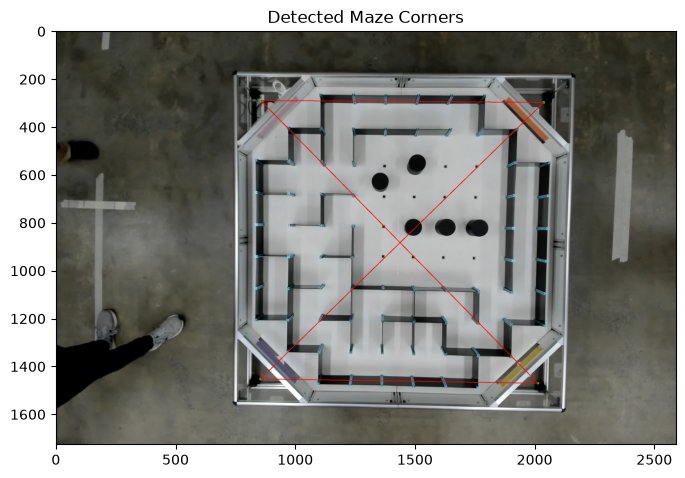

Image size: 1620 x 1620
Cell size: 180 x 180


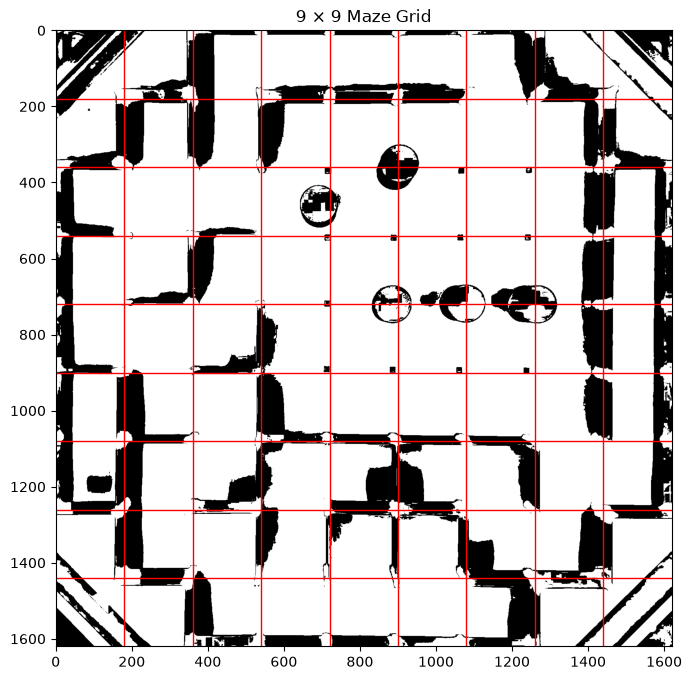

+---+---+---+---+---+---+---+---+---+
|       |                   |       |
+   +---+   +---+---+---+   +---+   +
    |   |   |                   |    
+---+   +   +   +   +   +   +   +---+
|               |               |   |
+---+   +---+   +   +   +   +   +   +
|       |                       |   |
+   +---+   +   +   +---+---+---+   +
|           |                   |   |
+---+   +---+   +   +   +   +   +   +
|   |       |                   |   |
+   +---+   +---+---+---+---+   +   +
|   |       |       |       |       |
+---+   +---+   +---+---+   +   +---+
    |       |   |   |   |       |    
+   +---+   +   +   +   +---+---+   +
|       |                   |        
+---+   +---+---+---+---+---+   +---+

Obstacle area: 900 x 900 pixels

Detected black regions:

Final occupancy map:
Size: 900 x 900
Occupied pixels: 346894
Free pixels: 463106

Occupancy map size: 900 x 900 pixels


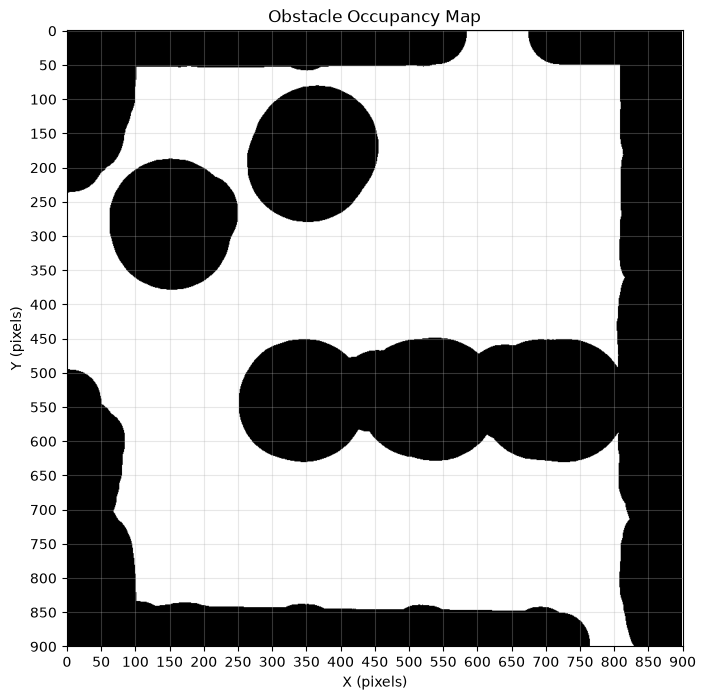

In [4]:
# Task 1.1 (1 mark): Display the occupancy map
binary, transformed_image = load_and_process_image(image_file)
black_cells = [
        0, 1, 7, 8,
        9, 17,
        63, 71,
        72, 73, 79, 80]

cells, cell_width, cell_height = split_into_cells(binary, bfs_n)
print("Image size:", binary.shape[1], "x", binary.shape[0])
print("Cell size:", cell_width, "x", cell_height)
display_occupancy_map(binary, cell_width, cell_height, bfs_n)
maze = detect_maze_walls(cells, bfs_n)
graph = create_grid_graph(bfs_n)
synchronise_walls(graph, maze, bfs_n)

print_maze(graph)

occupancy_map = create_obstacle_occupancy_map(
        binary_image=binary,
        graph=graph,
        rows=bfs_n,
        cols=bfs_n,
        top_left= top_left_index_coords,
        obstacle_cells=5,
        obstacle_buffer=40,
        wall_buffer=45,
        min_area=500,
        edge_margin=50,
        output_size=900
    )

print("\nOccupancy map size:", occupancy_map.shape[1], "x", occupancy_map.shape[0], "pixels")

plt.figure(figsize=(8, 8))
plt.imshow(occupancy_map,cmap="gray_r",origin="upper")

plt.title("Obstacle Occupancy Map")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")

plt.xticks(np.arange(0, occupancy_map.shape[1] + 1, 50))
plt.yticks(np.arange(0, occupancy_map.shape[0] + 1, 50))
plt.grid(True, alpha=0.3)
plt.show()


In [5]:
# 4. Find path using BFS
path_to_start_obst, commands_start = command_optimal_path_to_obstacles(graph, bfs_start_node, top_left_obstacle_box_cell_num, course_width = 5, start_direction="S", cols=9)
path_to_end_obst, commands_end = command_optimal_path_to_obstacles(graph, bfs_end_node, top_left_obstacle_box_cell_num, course_width = 5, start_direction="W", cols=9)

#reversed_path_to_end = path_to_end_obst[::-1]

if path_to_start_obst is None:
    print("\nNo path found.")
else:
    # Display the digital maze with the BFS path traced.
    print("\nDigital maze with path:")
    print_maze_with_path(graph, path_to_start_obst, bfs_n, bfs_n)
    print("\nPath:", path_to_start_obst)
    print("Number of moves:", len(path_to_start_obst) - 1)

if path_to_end_obst is None:
    print("\nNo path found.")
else:
    # Display the digital maze with the BFS path traced.
    print("\nDigital maze with path:")
    print_maze_with_path(graph, path_to_end_obst, bfs_n, bfs_n)
    print("\nPath:", path_to_end_obst)
    print("Number of moves:", len(path_to_end_obst) - 1)


No path found.

No path found.


# Task 2 - Graph Class (0 marks total)

NOTE: This is slightly different to the graph in lab 07. x,y variables have been added to the node object.

In [6]:
# This is a useful function that you may choose to implement and use 
# It looks through the image to see if the path is clear between one coordinate to the next
# Returns True or False 
def path_clear(image_to_analyse, x1, y1, x2, y2):
    n = int(np.ceil(np.sqrt((x2 - x1)**2 + (y2 - y1)**2)) + 1)
    x_coords = np.linspace(x1, x2, n).astype(int)
    y_coords = np.linspace(y1, y2, n).astype(int)
    colour_vals_actual = image_to_analyse[y_coords, x_coords]
    # Because both of the valid areas have no green values
    if np.any(colour_vals_actual[:] == 0):
        return False
    return True 

# Task 5 - Rapidly-exploring random trees (RRT) (7 marks total)

In [7]:
def cartesian_distance(x1, y1, x2, y2):
    return math.sqrt((x2-x1)**2 + (y2-y1)**2)

class RRT_Node:
    def __init__(self, node_id, x, y, parent = None, cost = 0.0):
        self.id = node_id
        self.x = x
        self.y = y
        self.children = []
        self.parent = parent
        self.cost = cost
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id 

    def add_child(self, child_node):
        self.children.append(child_node)

def nearest_node(tree, sample_x, sample_y):
    sample = RRT_Node(-1, sample_x, sample_y)  # temp node just to reuse distance()
    return min(tree, key=lambda n: cartesian_distance(n.x, n.y, sample.x, sample.y))

def steer(from_node, to_x, to_y):
    dist = cartesian_distance(to_x, to_y, from_node.x, from_node.y)
    if dist <= rrt_step_size:
        return to_x, to_y
    theta = math.atan2(to_y - from_node.y, to_x - from_node.x)
    new_x = from_node.x + rrt_step_size * math.cos(theta)
    new_y = from_node.y + rrt_step_size * math.sin(theta)
    return new_x, new_y

def near_nodes(tree, new_node):
    return [n for n in tree if cartesian_distance(n.x, n.y, new_node.x, new_node.y) <= rrt_max_connection_length]

def extend(tree, new_node, image):
    # 1. Pick the best parent among nearby nodes (not just the literal nearest)
    candidates = near_nodes(tree, new_node)
    if not candidates:
        return None  # no valid parent nearby

    best_parent = None
    best_cost = float('inf')
    for candidate in candidates:
        if path_clear(image, candidate.x, candidate.y, new_node.x, new_node.y):
            cost = candidate.cost + cartesian_distance(candidate.x, candidate.y, new_node.x, new_node.y)
            if cost < best_cost:
                best_cost = cost
                best_parent = candidate

    if best_parent is None:
        return None  # every candidate was blocked

    new_node.parent = best_parent
    new_node.cost = best_cost
    best_parent.children.append(new_node)
    tree.append(new_node)

    # 2. Rewire: check if new_node offers a cheaper path to its neighbors
    for candidate in candidates:
        if candidate is best_parent:
            continue
        potential_cost = new_node.cost + cartesian_distance(new_node.x, new_node.y, candidate.x, candidate.y)
        if potential_cost < candidate.cost and path_clear(image, new_node.x, new_node.y, candidate.x, candidate.y):
            # detach from old parent
            if candidate.parent is not None:
                candidate.parent.children.remove(candidate)
            candidate.parent = new_node
            propagate_cost(candidate, potential_cost - candidate.cost)
            new_node.children.append(candidate)

    return new_node

def propagate_cost(node, delta):
    # After a rewire, push the cost change down to all descendants
    node.cost += delta
    for child in node.children:
        propagate_cost(child, delta)

def get_path(goal_node):
    path = []
    current = goal_node
    while current is not None:
        path.append(current.get_point())
        current = current.parent
    path.reverse()
    return path

# RRT* stuff 

In [8]:
goal_bias = 0.05
rrt_max_nodes_count = 15

original_image_dims = 1620
obstacle_course_dims = 900

rrt_step_size = obstacle_course_dims // 6
rrt_max_connection_length = obstacle_course_dims // 6

def node_to_coords_original(node):
    row = node // 9
    col = node % 9
    coords = (col * 180, row * 180)
    return coords
    
def og_coord_to_obst(coord, obst_top_left_node_num):
    obst_coord = node_to_coords_original(obst_top_left_num)
    if coord[0]- obst_coord[0] < 0:
        return None
    
    if coord[1]- obst_coord[1] < 0: 
        return None
    
    return (coord[0]- obst_coord[0], coord[1]- obst_coord[1])


def node_to_obst_coord(node_num, obst_top_left_node_num):
    coord = node_to_coords_original(node_num)
    new_coord = og_coord_to_obst(coord, obst_top_left_node_num)
    return new_coords
    


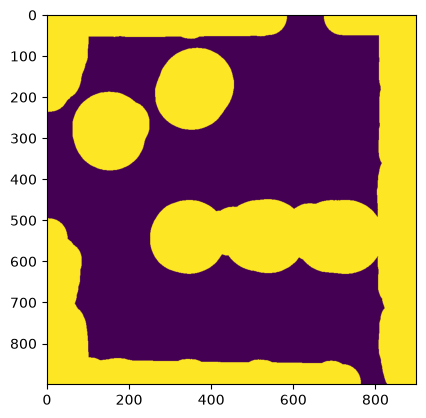

In [10]:
# Task 5.1 (4 marks): RRT/RRT*
# NOTE: The iteration only increases when a valid node is placed on the map. If the node is invalid, the program should continue without incrementing the node count. 
#image = cv2.imread("sample_map.png")
rrt_image = occupancy_map
#rrt_image = make_occupancy_map(rrt_image)
random.seed(seed)
#plt.imshow(occupancy_map,cmap="gray_r",origin="upper")
plt.imshow(rrt_image)

In [ ]:
#rrt_start_location = node_to_obst_coord(path_to_start_obst[-1],top_left_obstacle_box_cell_num )
rrt_start_location = (800, 850)
#rrt_goal_location = node_to_obst_coord(reversed_path_to_end[0], top_left_obstacle_box_cell_num)
rrt_goal_location = (75,450)

# Generate the start node with a node ID of -1

root = RRT_Node(-1, rrt_start_location[0], rrt_start_location[1], None, 0.0)
rrt_tree = [root]
goal_node = None

i = 0
while i < rrt_max_nodes_count:
    if random.random() < goal_bias:
        sample_x, sample_y = rrt_goal_location[0], rrt_goal_location[1]
    else:
        sample_x = random.randint(0, rrt_image.shape[1]-1)
        sample_y = random.randint(0, rrt_image.shape[0]-1)

    nearest = nearest_node(rrt_tree, sample_x, sample_y)
    new_x, new_y = steer(nearest, sample_x, sample_y)
    new_x, new_y = int(round(new_x)), int(round(new_y))

    # snap on if goal isnt created yet and within distance
    dist_to_goal = cartesian_distance(new_x, new_y, rrt_goal_location[0], rrt_goal_location[1])
    if goal_node is None and dist_to_goal <= rrt_step_size:
        new_x, new_y = rrt_goal_location

    # Potential node collision checks
    if rrt_image[new_y, new_x] != 1 or not path_clear(rrt_image, nearest.x, nearest.y, new_x, new_y):
        continue

    new_node = RRT_Node(i, new_x, new_y)
    new_node = extend(rrt_tree, new_node, rrt_image)
    if new_node is None:
        continue

    if goal_node is None and new_node.x == rrt_goal_location[0] and new_node.y == rrt_goal_location[1]:
        goal_node = new_node

    cv2.circle(rrt_image, new_node.get_point(), 3, (0, 255, 0), -1)
    
    i += 1


cv2.circle(rrt_image, root.get_point(), 3, (0, 255, 0), -1)

for node in rrt_tree:
    for child in node.children:
        cv2.line(rrt_image, node.get_point(), child.get_point(), (0, 125, 0), 1)

path = get_path(goal_node)

prev_i, prev_j = root.get_point()

for i in range(1, len(path)):
    cur_i, cur_j = path[i]
    cv2.line(rrt_image, (prev_i, prev_j), (cur_i, cur_j), (0, 0, 125), 2)

    prev_i = cur_i
    prev_j = cur_j

# Display the resulting image
plt.imshow(rrt_image)
plt.show()


print(path)

In [ ]:
"""
Converts an RRT*-style path of (x, y) pixel coordinates into a list of
(angle, distance) navigation instructions.

Coordinate system:
    (0, 0) is the top-left corner. x increases to the right, y increases
    downward (standard image convention).

Heading system:
    Headings are given as one of "N", "S", "E", "W":
        N = up    (-y)   -> bearing 0
        E = right (+x)   -> bearing 90
        S = down  (+y)   -> bearing 180
        W = left  (-x)   -> bearing 270
    Bearings increase clockwise (visually), matching a standard compass.

Output:
    A list of (angle, distance) tuples.
    - angle: degrees to rotate *before* moving `distance`, relative to the
      current heading. Clockwise = negative, counter-clockwise = positive.
      Range: (-180, 180].
    - distance: raw pixel distance to travel after turning (float).

    The final tuple in the list is always (angle, 0) - a turn-in-place
    at the last waypoint to rotate from the path's final direction of
    travel to `end_heading`. No distance is traveled for this step.
"""

# Compass bearing (degrees, clockwise from north) for each cardinal heading.
_HEADING_TO_BEARING = {
    "N": 0.0,
    "E": 90.0,
    "S": 180.0,
    "W": 270.0,
}


def _normalize_angle(angle: float) -> float:
    """Normalize an angle in degrees to the range (-180, 180]."""
    normalized = (angle + 180.0) % 360.0 - 180.0
    # (a + 180) % 360 - 180 gives [-180, 180). Nudge -180 -> 180 to match
    # the documented (-180, 180] range.
    if normalized <= -180.0:
        normalized += 360.0
    return normalized


def _bearing_from_delta(dx: float, dy: float) -> float:
    """
    Compass bearing (0-360, clockwise from north/up) of the vector (dx, dy)
    in an image coordinate system where y increases downward.
    """
    bearing = math.degrees(math.atan2(dx, -dy))
    return bearing % 360.0


def path_to_instructions(
    path: Sequence[Tuple[float, float]],
    start_heading: str,
    end_heading: str,
) -> List[Tuple[float, float]]:
    """
    Convert a path of (x, y) pixel waypoints into (angle, distance)
    navigation instructions.

    Args:
        path: Ordered list of (x, y) pixel coordinates, (0, 0) = top-left.
              Must contain at least 1 point.
        start_heading: One of "N", "S", "E", "W" - the heading before the
              first move.
        end_heading: One of "N", "S", "E", "W" - the heading the traveler
              should be facing once the path is complete.

    Returns:
        List of (angle, distance) tuples. `angle` is the turn (degrees,
        clockwise negative) to make before traveling `distance` (pixels).
        The last tuple is always (angle, 0), a final turn-in-place to
        reach `end_heading`. Zero-length movement segments (duplicate
        consecutive points) are skipped.

    Raises:
        ValueError: if start_heading/end_heading are invalid, or path is
              empty.
    """
    start_heading = start_heading.upper()
    end_heading = end_heading.upper()

    if start_heading not in _HEADING_TO_BEARING:
        raise ValueError(f"start_heading must be one of N/S/E/W, got {start_heading!r}")
    if end_heading not in _HEADING_TO_BEARING:
        raise ValueError(f"end_heading must be one of N/S/E/W, got {end_heading!r}")
    if len(path) < 1:
        raise ValueError("path must contain at least one point")

    instructions: List[Tuple[float, float]] = []

    current_heading_bearing = _HEADING_TO_BEARING[start_heading]

    for i in range(len(path) - 1):
        x1, y1 = path[i]
        x2, y2 = path[i + 1]
        dx = x2 - x1
        dy = y2 - y1

        distance = math.hypot(dx, dy)
        if distance == 0:
            # Skip duplicate consecutive points - no movement, no turn info.
            continue

        segment_bearing = _bearing_from_delta(dx, dy)
        turn = _normalize_angle(-(segment_bearing - current_heading_bearing))

        instructions.append((round(turn, 1), round(distance, 1)))
        current_heading_bearing = segment_bearing

    # Final turn-in-place to face end_heading.
    end_bearing = _HEADING_TO_BEARING[end_heading]
    final_turn = _normalize_angle(-(end_bearing - current_heading_bearing))
    instructions.append((round(final_turn, 1), 0.0))

    return instructions


if __name__ == "__main__":
    
    result = path_to_instructions(path, start_heading="E", end_heading="N")
    #for angle, dist in result:
     #print(f"turn {angle:7.2f} deg, then move {dist:7.2f} px")
    print(result)